# AI Workshop #4
# Predictive Analytics with Ensemble Learning

## 4.1. Introduction

In this workshop, we will learn about ensemble learning and how to use it for 
predictive analytics. 

By the end of this workshop, you will have a better understanding of these topics:
- Decision trees and decision trees classifiers
- Learning models with ensemble learning
- Random forests and extremely random forests
- Confidence measure estimation of predictions
- Dealing with class imbalance
- Finding optimal training parameters using grid search
- Computing relative feature importance
- Traffic prediction using the extremely random forests regressor

Let's begin with **decision trees**. Firstly, what are they?

## 4.2 What are decision trees?

A decision tree is a way to partition a dataset into distinct branches. 

The branches or partitions are then traversed to make simple decisions. Decision trees are produced by training algorithms, which identify how to split the data in an optimal way.

The decision process starts at the root node at the top of the tree. Each node in the 
tree is a decision rule. Algorithms construct these rules based on the relationship 
between the input data and the target labels in the training data. The values in the 
input data are utilized to estimate the value of the output.

The following shows a Decision Tree for the decision of Job Offering. 

<img src="./Fig/Fig4.1.png" width = "" height = "" alt="Decision Tree" align=center />

Now that we understand the basic concept behind decision trees, the next concept to 
understand is how the trees are automatically constructed. 

We need algorithms that can construct the optimal tree based on the data. In order to understand it, we need to understand the concept of entropy. In this context, entropy refers to information entropy and not thermodynamic entropy. Information entropy is basically a measure of uncertainty. 

One of the main goals of a decision tree is to reduce uncertainty as we move from the root node towards the leaf nodes. 

When we see an unknown data point, we are completely uncertain about the output. 

By the time we reach the leaf node, we are certain about the output. 

This means that the decision tree needs to be constructed in a way that will reduce the uncertainty at each level. 

This implies that we need to reduce the entropy as we progress down the tree.

## Building a decision tree classifier

Let's see how to build a classifier using decision trees in Python. 

1. Create a new Python file and import the following packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from utilities import visualize_classifier

We will be using the data in the **data_decision_trees.txt** file that's provided 
to you. In this file, each line contains comma-separated values. The first two values 
correspond to the input data and the last value corresponds to the target label. 

2. Let's load the data from that file:

In [2]:
# Load input data
input_file = 'data_decision_trees.txt'
data = np.loadtxt(input_file, delimiter=',')
X, y = data[:, :-1], data[:, -1]

3. Check the data contains in X and y:

In [3]:
X

array([[ 4.86,  4.87],
       [ 4.69,  5.37],
       [ 3.82,  5.71],
       [ 2.58,  9.88],
       [ 8.3 ,  5.36],
       [ 3.41,  1.46],
       [ 4.4 ,  5.77],
       [ 5.35,  5.02],
       [ 4.77,  5.03],
       [ 2.18,  8.08],
       [ 7.41,  5.87],
       [ 2.6 ,  1.7 ],
       [ 6.39,  6.26],
       [ 4.83,  3.62],
       [ 5.82,  4.95],
       [ 1.88,  7.33],
       [ 7.93,  6.52],
       [ 3.1 ,  3.05],
       [ 4.44,  5.09],
       [ 5.69,  5.35],
       [ 5.11,  5.76],
       [ 2.02,  8.78],
       [ 8.9 ,  4.67],
       [ 2.53,  2.63],
       [ 5.56,  4.9 ],
       [ 3.79,  5.27],
       [ 5.45,  4.65],
       [ 3.54,  7.7 ],
       [ 6.44,  4.94],
       [ 3.34,  2.62],
       [ 5.24,  6.22],
       [ 4.28,  4.92],
       [ 4.75,  5.88],
       [ 2.35,  7.94],
       [ 7.86,  4.65],
       [ 4.47,  1.69],
       [ 4.19,  5.53],
       [ 4.58,  4.97],
       [ 4.81,  4.95],
       [ 2.88,  7.87],
       [ 7.21,  5.37],
       [ 2.46,  2.61],
       [ 5.77,  5.61],
       [ 5.

In [5]:
y

array([0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 1.

4. Separate the input data into two separate classes based on the labels:

In [6]:
# Separate input data into two classes based on labels
class_0 = np.array(X[y==0])
class_1 = np.array(X[y==1])

In [7]:
class_0

array([[4.86, 4.87],
       [4.69, 5.37],
       [3.82, 5.71],
       [4.4 , 5.77],
       [5.35, 5.02],
       [4.77, 5.03],
       [6.39, 6.26],
       [4.83, 3.62],
       [5.82, 4.95],
       [4.44, 5.09],
       [5.69, 5.35],
       [5.11, 5.76],
       [5.56, 4.9 ],
       [3.79, 5.27],
       [5.45, 4.65],
       [5.24, 6.22],
       [4.28, 4.92],
       [4.75, 5.88],
       [4.19, 5.53],
       [4.58, 4.97],
       [4.81, 4.95],
       [5.77, 5.61],
       [5.13, 4.87],
       [5.9 , 2.26],
       [4.73, 6.74],
       [5.27, 5.62],
       [4.62, 5.77],
       [4.81, 5.5 ],
       [4.16, 4.88],
       [4.34, 3.7 ],
       [5.42, 4.57],
       [4.67, 5.04],
       [4.49, 5.13],
       [5.07, 5.19],
       [3.96, 4.93],
       [4.27, 4.45],
       [6.03, 5.69],
       [4.08, 4.96],
       [5.67, 5.57],
       [5.48, 4.92],
       [4.39, 3.83],
       [4.75, 4.6 ],
       [4.55, 4.87],
       [5.44, 6.27],
       [5.4 , 3.88],
       [4.55, 5.29],
       [4.52, 6.22],
       [5.03,

class_1

5. Let's visualize the input data using a scatter plot:

<USER_HOME>\AppData\Local\Temp\ipykernel_41640\3721073358.py:3: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(class_0[:, 0], class_0[:, 1], s=75, facecolors='black',edgecolors='black', linewidth=1, marker='x')


Text(0.5, 1.0, 'Input data')

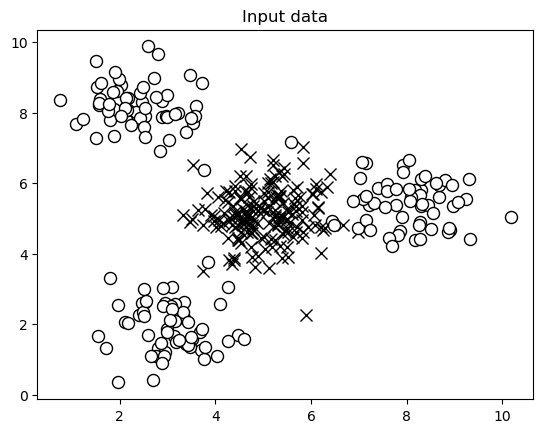

In [12]:
# Visualize input data
plt.figure()
plt.scatter(class_0[:, 0], class_0[:, 1], s=75, facecolors='black',edgecolors='black', linewidth=1, marker='x')
plt.scatter(class_1[:, 0], class_1[:, 1], s=75, facecolors='white',edgecolors='black', linewidth=1, marker='o')
plt.title('Input data')

6. We need to split the data into training and testing datasets:

In [14]:
# Split data into training and testing datasets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=5)

7. Create, build, and visualize a decision tree classifier based on the training dataset. The random_state parameter refers to the seed used by the random number generator required for the initialization of the decision tree classification algorithm. The max_depth parameter refers to the maximum depth of the tree that we want to construct:

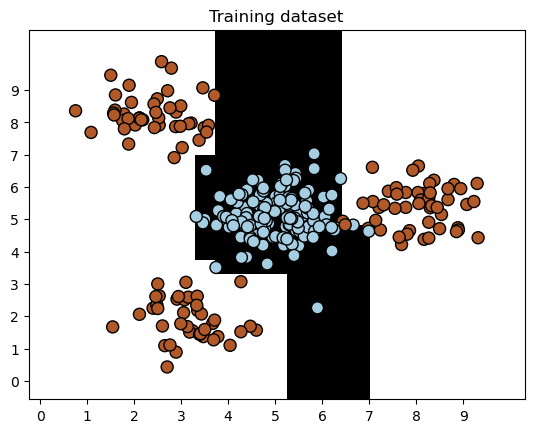

In [15]:
# Decision Trees classifier
params = {'random_state': 0, 'max_depth': 4}
classifier = DecisionTreeClassifier(**params)
classifier.fit(X_train, y_train)
visualize_classifier(classifier, X_train, y_train, 'Training dataset')

8. Compute the output of the classifier on the test dataset and visualize it:

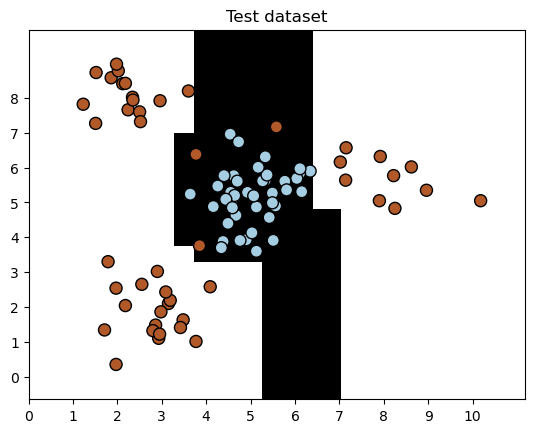

In [16]:
y_test_pred = classifier.predict(X_test)
visualize_classifier(classifier, X_test, y_test, 'Test dataset')

9. Evaluate the performance of the classifier by printing the classification report:

In [17]:
# Evaluate classifier performance
class_names = ['Class-0', 'Class-1']
print("\n" + "#"*40)
print("\nClassifier performance on training dataset\n")
print(classification_report(y_train, classifier.predict(X_train), target_names=class_names))
print("#"*40 + "\n")

print("#"*40)
print("\nClassifier performance on test dataset\n")
print(classification_report(y_test, y_test_pred, target_names=class_names))
print("#"*40 + "\n")

plt.show()


########################################

Classifier performance on training dataset

              precision    recall  f1-score   support

     Class-0       0.99      1.00      1.00       137
     Class-1       1.00      0.99      1.00       133

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270

########################################

########################################

Classifier performance on test dataset

              precision    recall  f1-score   support

     Class-0       0.93      1.00      0.97        43
     Class-1       1.00      0.94      0.97        47

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90

########################################



<img src="./Fig/note.png" width = "" height = "" alt="Supervised ML" align=left />

The performance of a classifier is characterized by **precision, recall, and F1-
scores**. **Precision** refers to the accuracy of the classification, and **recall** refers to the number of items that were retrieved as a percentage of the overall number of items that were supposed to be retrieved. 

A good classifier will have high precision and high recall, but there is usually a trade-off between the two. Hence, we have **F1-score** to characterize that. F1 score is the harmonic mean of precision and recall, which gives it a good balance between precision and recall values.

**Decision trees** are an example of using a single model to make a prediction. It is 
possible to sometimes create stronger models and better predictions by combining 
and aggregating the results of multiple models. 

One way to do is to use ensemble learning, which will be discussed in the next section.

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center/>

### Workshop 4.1 : Decision Tree with Modified Dataset

1. By modifying the classification of 20% of the training data, try to show the decision tree classification result and compared with the previous results. What is your findings. 
2. Try to modify 20% of the testset classification as well and compare the results. 


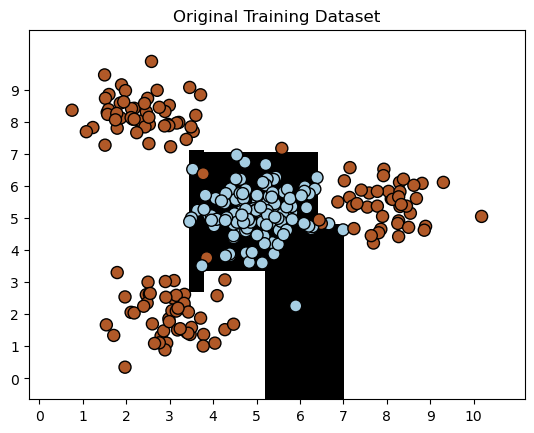

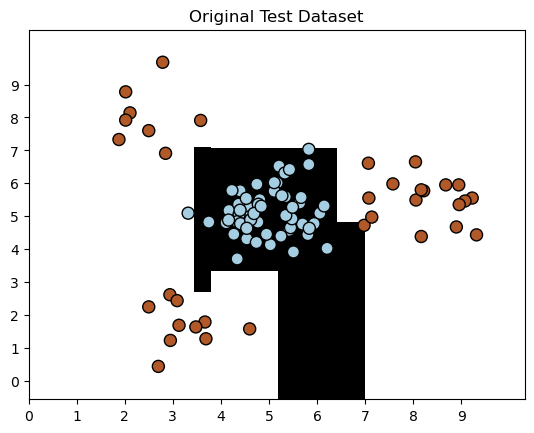

before modify-Classifier performance on training dataset
              precision    recall  f1-score   support

     Class-0       0.98      1.00      0.99       125
     Class-1       1.00      0.99      0.99       145

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270

before modify-Classifier performance on test dataset
              precision    recall  f1-score   support

     Class-0       0.98      0.98      0.98        55
     Class-1       0.97      0.97      0.97        35

    accuracy                           0.98        90
   macro avg       0.98      0.98      0.98        90
weighted avg       0.98      0.98      0.98        90



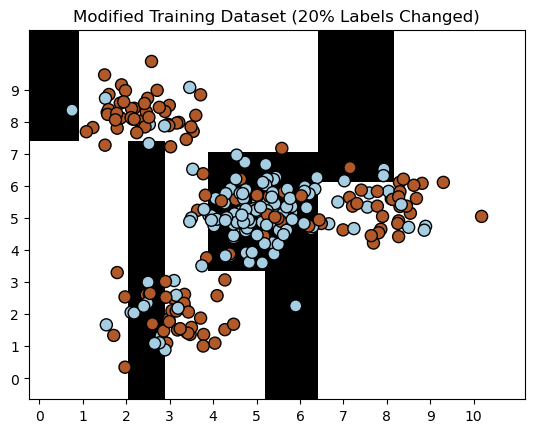

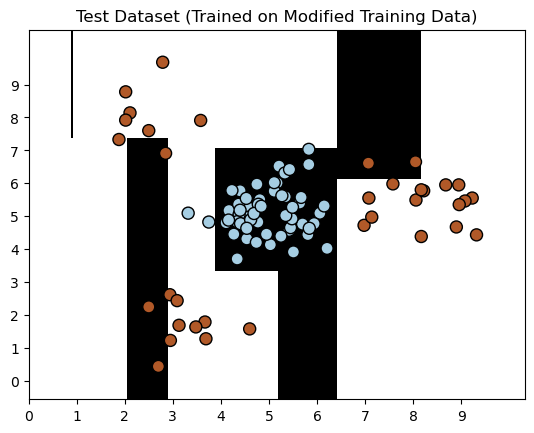

after modify-Classifier performance on training dataset
              precision    recall  f1-score   support

     Class-0       0.81      0.83      0.82       133
     Class-1       0.83      0.81      0.82       137

    accuracy                           0.82       270
   macro avg       0.82      0.82      0.82       270
weighted avg       0.82      0.82      0.82       270

after modify-Classifier performance on test dataset
              precision    recall  f1-score   support

     Class-0       0.91      0.96      0.94        55
     Class-1       0.94      0.86      0.90        35

    accuracy                           0.92        90
   macro avg       0.93      0.91      0.92        90
weighted avg       0.92      0.92      0.92        90



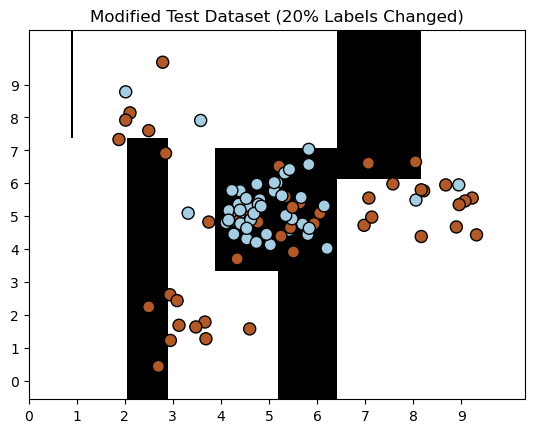

after modify 20% of the testset and 20% of the training data -Classifier performance on training dataset
              precision    recall  f1-score   support

     Class-0       0.69      0.89      0.78        45
     Class-1       0.84      0.60      0.70        45

    accuracy                           0.74        90
   macro avg       0.77      0.74      0.74        90
weighted avg       0.77      0.74      0.74        90



In [37]:
##The result of modifying the classification of 20% of the training data and modify 20% of the testset classification.
##Here is the code part, and I will discribe my finding in the next cell.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from utilities import visualize_classifier

input_file = 'data_decision_trees.txt'
data = np.loadtxt(input_file, delimiter=',')
X, y = data[:, :-1], data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

params = {'random_state': 0, 'max_depth': 4}

classifier_original = DecisionTreeClassifier(**params)
classifier_original.fit(X_train, y_train)

y_train_pred_original = classifier_original.predict(X_train)
y_test_pred_original = classifier_original.predict(X_test)

visualize_classifier(classifier_original, X_train, y_train, 'Original Training Dataset')
visualize_classifier(classifier_original, X_test, y_test, 'Original Test Dataset')

print("before modify-Classifier performance on training dataset")
print(classification_report(y_train, y_train_pred_original, target_names=['Class-0', 'Class-1']))
print("before modify-Classifier performance on test dataset")
print(classification_report(y_test, y_test_pred_original, target_names=['Class-0', 'Class-1']))

# modifying the classification of 20% of the training data
n_modify_train = int(0.2 * len(y_train))
np.random.seed(42)
modify_indices_train = np.random.choice(len(y_train), n_modify_train, replace=False)
y_train_modified = y_train.copy()
y_train_modified[modify_indices_train] = 1 - y_train_modified[modify_indices_train]

classifier_train_modified = DecisionTreeClassifier(**params)
classifier_train_modified.fit(X_train, y_train_modified)

y_train_pred_modified = classifier_train_modified.predict(X_train)
y_test_pred_modified = classifier_train_modified.predict(X_test)

visualize_classifier(classifier_train_modified, X_train, y_train_modified, 'Modified Training Dataset (20% Labels Changed)')
visualize_classifier(classifier_train_modified, X_test, y_test, 'Test Dataset (Trained on Modified Training Data)')

print("after modify-Classifier performance on training dataset")
print(classification_report(y_train_modified, y_train_pred_modified, target_names=['Class-0', 'Class-1']))
print("after modify-Classifier performance on test dataset")
print(classification_report(y_test, y_test_pred_modified, target_names=['Class-0', 'Class-1']))

# modify 20% of the testset classification
n_modify_test = int(0.2 * len(y_test))
modify_indices_test = np.random.choice(len(y_test), n_modify_test, replace=False)
y_test_modified = y_test.copy()
y_test_modified[modify_indices_test] = 1 - y_test_modified[modify_indices_test]

y_test_pred_modified_final = classifier_train_modified.predict(X_test)
visualize_classifier(classifier_train_modified, X_test, y_test_modified, 'Modified Test Dataset (20% Labels Changed)')
print("after modify 20% of the testset and 20% of the training data -Classifier performance on training dataset")
print(classification_report(y_test_modified, y_test_pred_modified_final, target_names=['Class-0', 'Class-1']))


## 4.3 What is ensemble learning?

**Ensemble learning** involves building multiple models and then combining them 
in such a way that it produces better results than what the models could produce 
individually. 

These individual models can be classifiers, regressors, or other models.

Ensemble learning is used extensively across multiple fields, including data 
classification, predictive modeling, and anomaly detection.

So why use ensemble learning? In order to gain understanding, let's use a real-life 
example. You want to buy a new TV, but you don't know what the latest models 
are. Your goal is to get the best value for your money, but you don't have enough 
knowledge on this topic to make an informed decision. When you must decide about 
something like this, you might get the opinions of multiple experts in the domain. 
This will help you make the best decision. Often, instead of relying on one opinion, 
you can decide by combining the individual decisions of those experts. Doing this 
minimizes the possibility of making a wrong or suboptimal decision.


## Building learning models with ensemble learning

While selecting a model, a commonly used procedure is to choose the one with the 
smallest error on the training dataset. The problem with this approach is that it will not always work. The model might become biased or overfit the training data. Even when 
training the model using cross-validation, it can perform poorly on unknown data.

A reason why ensemble learning models are effective is because they reduce the 
overall risk of making a poor model selection. This enables it to train in a diverse 
manner and then perform well on unknown data. When a model is built using 
ensemble learning, the individual models need to exhibit some diversity. This 
allows them to capture various nuances in the data; hence the overall model 
becomes more accurate.

The diversity is achieved by using different training parameters for each individual 
model. This allows individual models to generate different decision boundaries 
for training data. This means that each model will use different rules to make an 
inference, which is a powerful way of validating the result. If there is agreement 
among the models, this increases the confidence in the prediction.

A special type of an ensemble learning is when you combine decision trees into 
an ensemble. These models are usually known as random forests and extremely 
random forests, which we'll describe in the coming sections.


## What are random forests and extremely random forests?

A **random forest** is an instance of ensemble learning where individual models 
are constructed using decision trees. This ensemble of decision trees is then used 
to predict the output value. We use a random subset of training data to construct 
each decision tree.

This will ensure diversity among various decision trees. In the first section, we 
discussed that one of the most important attributes when building good ensemble 
learning models is that we ensure that there is diversity among individual models.

One of the advantages of random forests is that they do not overfit. Overfitting is a 
frequent problem in machine learning. Overfitting is more likely with nonparametric 
and nonlinear models that have more flexibility when learning a target function. By 
constructing a diverse set of decision trees using various random subsets, we ensure 
that the model does not overfit the training data. During the construction of the 
tree, the nodes are split successively, and the best thresholds are chosen to reduce 
the entropy at each level. This split doesn't consider all the features in the input 
dataset. Instead, it chooses the best split among the random subset of the features 
that is under consideration. Adding this randomness tends to increase the bias of 
the random forest, but the variance decreases because of averaging. Hence, we end 
up with a robust model.

**Extremely random forests** take randomness to the next level. Along with taking 
a random subset of features, the thresholds are chosen randomly as well. These 
randomly generated thresholds are chosen as the splitting rules, which reduce the 
variance of the model even further. Hence, the decision boundaries obtained using 
extremely random forests tend to be smoother than the ones obtained using random 
forests. Some implementations of extremely random forest algorithms also enable 
better parallelization and can scale better.

## Building random forest and extremely random forest classifiers

Let's see how we can build a classifier based on random forests and extremely
random forests. The way to construct both classifiers is very similar, so an input 
flag is used to specify which classifier needs to be built.

1. Create a new Python file and import the following packages:

In [38]:
import argparse 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report

from utilities import visualize_classifier

2. Define an argument parser for Python so that we can take the classifier type as an input parameter. Depending on this parameter, we can construct a random forest classifier or an extremely random forest classifier:

In [39]:
# Argument parser 
def build_arg_parser():
    parser = argparse.ArgumentParser(description='Classify data using \
            Ensemble Learning techniques')
    parser.add_argument('--classifier-type', dest='classifier_type', 
            required=True, choices=['rf', 'erf'], help="Type of classifier \
                    to use; can be either 'rf' or 'erf'")
    return parser

3. Define the main function and parse the input arguments:

4. We will be using the data from the data_random_forests.txt file that is provided to you. Each line in this file contains comma-separated values. The first two values correspond to the input data and the last value corresponds to the target label. We have three distinct classes in this dataset. Let's load the data from that file:

5. Separate the input data into three classes:

6. Let's visualize the input data:

7. Split the data into training and testing datasets:

8. Define the parameters to be used when we construct the classifier. The **n_estimators** parameter refers to the number of trees that will be constructed. The **max_depth** parameter refers to the maximum number of levels in each tree. The **random_state** parameter refers to the seed value of the random number generator needed to initialize the random forest classifier algorithm:

9. Depending on the input parameter, we either construct a random forest classifier or an extremely random forest classifier:

10. Train and visualize the classifier:

11. Compute the output based on the test dataset and visualize it:

12. Evaluate the performance of the classifier by printing the classification report:

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center />

### Workshop 4.2 : Construct random_forests.py

1. Combine the code fragment of the above and construct the complete random_forests.py program code. 
2. Run the code with the random forest classifier using the **rf** flag in the input argument by running the following command:

$ python random_forests.py --classifier-type rf

3. Save the two figures (if you are successful) into the following for submission. 

4. Now run the code with the extremely random forest classifier by using the erf
flag in the input argument. Run the following command:

$ python random_forests.py --classifier-type erf

5. You should see a few figures pop up. Save these figures for submission. 

6. If you compare the preceding screenshot with the boundaries obtained from the random forest classifier, you will see that these boundaries are smoother.Why. Please explain. 



## Estimating the confidence measure of the predictions

If you analyze the output, you will see that the probabilities are printed for each data 
point. These probabilities are used to measure the confidence values for each class. 
Estimating the confidence values is an important task in machine learning. 

13. In the same Python file, add the following line to define an array of test data points:

14. The classifier object has an inbuilt method to compute the confidence measure. Let's classify each point and compute the confidence values:

15. Visualize the test data points based on classifier boundaries:

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center />

### Workshop 4.3 : Construct random_forests.py + Confidence Measure

1. Combine the code **Random_Forecasts.py** with the above confidlence Measure to produce random_forests_Conf.py.
2. Run the code with **erf** flag. Save the output for submission. 

## 4.4 Dealing with class imbalance

A classifier is only as good as the data that is used for training. 

A common problem faced in the real world is issues with data quality. For a classifier to perform well, it needs to see an equal number of points for each class. 

But when data is collected in the real world, it's not always possible to ensure that each class has the exact same number of data points. 

If one class has 10 times the number of data points than another class, then the classifier tends to get biased towards the more numerous class. 

Hence, we need to make sure that we account for this imbalance algorithmically. 

Let's see how to do that.

1. Create a new Python file and import the following packages:

2. We will use the data in the file **data_imbalance.txt** for our analysis. Let's load the data. Each line in this file contains comma-separated values. The first two values correspond to the input data, and the last value corresponds to the target label. We have two classes in this dataset. Let's load the data from that file:

3. Separate the input data into two classes:

4. Visualize the input data using a scatter plot:

5. Split the data into training and testing datasets:

6. Next, we define the parameters for the extremely random forest classifier. 

Note that there is an input parameter called **balance** that controls whether to algorithmically account for class imbalance. If so, another parameter needs to be added called **class_weight** that tells the classifier that it should balance the weight so that it's proportional to the number of data points in each class:

7. Build, train, and visualize the classifier using training data:

8. Predict the output for the test dataset and visualize the output:

9. Compute the performance of the classifier and print the classification report:

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center />

### Workshop 4.4 : Construct class_imbalance.py
1. Combine the code fragment of the above and construct the complete **class_imbalance.py** program code. 
2. Run the code and you should see the two graphics: Input Data and Test Dataset which shows the classifier boundary for the test dataset. Save and submit these TWO figures. 
3. You should see  that the boundary was not able to capture the actual boundary between the two classes. The black patch near the top represents the boundary. Why? Please explain. 
4. Finally you will see the classifier performance table. Save and submit it. 
5. You see a warning because the values are 0 in the first row, which leads to a divide-by-zero error (ZeroDivisionError exception) when we compute the f1-score. Run the code using the ignore flag so that you do not see the divide-by-zero warning:

$ python -W ignore class_imbalance.py

6. Now, if you want to account for class imbalance, run it with the balance flag:

$ python class_imbalance.py balance

7. The problem should be solved. Right? Please save and submit the new Classifier Figure and Classifier Performance table. 


## 4.5 Finding optimal training parameters using grid search

When working with classifiers, it is not always possible to know what the best 
parameters are to use. 

It is not efficient to use brute force by checking for all 
possible combinations manually. 

This is where grid search becomes useful. **Grid search** allows us to specify a range of values and the classifier will automatically run various configurations to figure out the best combination of parameters. 

Let's see how to do it.

1. Create a new Python file and import the following packages:

Noted that we use the **grid search** class provided in this directory. 

2. We will use the data available in data_random_forests.txt for analysis:

3. Separate the data into three classes:

4. Split the data into training and testing datasets:

5. Specify the grid of parameters for the classifier to test. Usually one parameter is kept constant and the other parameter is varied. Then the inverse is done to figure out the best combination. In this case, we want to find the best values for n_estimators and max_depth. Let's specify the parameter grid:

6. Let's define the metrics that the classifier should use to find the best combination of parameters:

7. For each metric, we need to run the grid search, where we train the classifier for a combination of parameters:

8. Print the score for each parameter combination and the performance report:

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center />

### Workshop 4.5 : Construct run_grid_search.py


1. Combine the code fragment of the above and construct the complete **run_grid_search.py** Python program.

2. Run the code (if successful) you will see TWO reports: 
    ##### Searching optimal parameters for precision_weighted
      Grid scores for the parameter grid:
      0.849757 with:   {'max_depth': 2, 'n_estimators': 100}
      ....
      
    ##### Searching optimal parameters for recall_weighted
      Grid scores for the parameter grid:
      0.842963 with:   {'max_depth': 2, 'n_estimators': 100}
      ....
      
3. Save and submit these two report for submission. 
4. One final step: Amend the program code and output the BEST Parameters. What is the Best Parameters. 
5. Save and submit the BEST Parameter results. 

## 4.6 Computing relative feature importance

When working with a dataset that contains N-dimensional data points, it must be 
understood that not all features are equally important. Some are more discriminative 
than others. If we have this information, we can use it to reduce the dimensionality. 
This is useful in reducing the complexity and increasing the speed of the algorithm. 
Sometimes, a few features are completely redundant. Hence, they can be easily 
removed from the dataset.

We will be using the AdaBoost regressor to compute feature importance. AdaBoost, 
short for Adaptive Boosting, is an algorithm that's frequently used in conjunction 
with other machine learning algorithms to improve their performance. In AdaBoost, 
the training data points are drawn from a distribution to train the current classifier. 
This distribution is updated iteratively so that the subsequent classifiers get to 
focus on the more difficult data points. The difficult data points are the ones that 
are misclassified. This is done by updating the distribution at each step. This will 
make the data points that were previously misclassified more likely to come up 
in the next sample dataset that's used for training.

These classifiers are then cascaded, and the decision is taken through weighted 
majority voting.

1. Create a new Python file and import the following packages:

2. We will use the Boston Housing Dataset provided by the workshop:

3. Shuffle the data so that we don't bias our analysis:

4. Split the dataset into training and testing:

5. Define and train an AdaBoostregressor using the decision tree regressor as the individual model:

6. Estimate the performance of the regressor:

7. This regressor has an inbuilt method that can be called to compute the relative feature importance:

8. Normalize the values of the relative feature importance:

9. Sort them so that they can be plotted:

10. Arrange the ticks on the x axis for the bar graph:

9. Use **plt.figure()** to plot the graph. 

If successful, it should be like this:

<img src="./Fig/Fig4.2.png" width = "" height = "Feature Importance" alt="" align=center/>

<img src="./Fig/workshop.png" width = "" height = "" alt="Supervised ML" align=center />

### Workshop 4.6 : Construct feature_importance.py


1. Combine the code fragment of the above and construct the complete **feature_importance.py** Python program.
2. Run the code (if successful) you should see the above chart. 
3. Save and submit the chart. 
4. What is the TOP 4 feature attributes? Why?

<img src="./Fig/mini-project.png" width = "" height = "" alt="Mini-project" align=center />


## 4.7 Mini-project : Predicting traffic using an extremely random forest regressor

Let's apply the concepts learned in the previous sections to a real-world problem. 
A dataset available at will be used: 'traffic_data.txt'.

This dataset consists of data that counts the number of vehicles passing by on the road during baseball games played at Los Angeles Dodgers stadium. In order to make the data readily available for analysis, we need to pre-process it. 

The pre-processed data is in the file traffic_data.txt. In this file, 
each line contains comma-separated strings. Let's take the first line as an example:

            Tuesday,00:00,San Francisco,no,3

With reference to the preceding line, it is formatted as follows:

Day of the week, time of the day, opponent team, binary value indicating whether 
a baseball game is currently going on (yes/no), number of vehicles passing by.

Our goal is to predict the number of vehicles going by using the given information. 
Since the output variable is continuous valued, we need to build a regressor that can 
predict the output. We will be using extremely random forests to build this regressor. 
Let's go ahead and see how to do that.

If your program works: you result should be like that:

Test datapoint: = ['Saturday', '10:20', 'Atlanta', 'no']

Mean absolute error: 7.42

Predicted traffic: 6

Or you allow people to input any Data, Time, Location and the system will predict the traffic at that moment for you. 

Let's try!!!


## Summary 

In this workshop, we learned about ensemble learning and how it can be used in the 
real world. We discussed decision trees and how to build a classifier based on it.

We learned about random forests and extremely random forests, which are created 
from ensembling multiple decision trees. We discussed how to build classifiers based 
on them. We understood how to estimate the confidence measure of the predictions. 

We also learned how to deal with the class imbalance problem.

We discussed how to find the most optimal training parameters to build the models 
using grid search. We learned how to compute relative feature importance. 

We then applied ensemble learning techniques to a real-world problem, where we predicted 
traffic using an extremely random forest regressor.

In the next workshop, we will discuss unsupervised learning and how to detect 
patterns in stock market data.